# Debug Embedding Geometry (PCA + UMAP)

This notebook is a focused workflow for debugging why pooled embeddings can look
"disconnected" or oddly segmented in 2D projections.

It includes:
- Full-train embedding extraction from the frozen backbone
- PCA variance analysis and annotated PCA scatter
- UMAP projection and annotated UMAP scatter
- Quantitative checks linking geometry to `#valid_peaks`, precursor m/z, and labels
- Connectivity diagnostics in high-D vs. 2D

In [1]:
import os
import sys

os.chdir(
    os.path.join(
        os.path.dirname(os.getcwd())
        if os.path.basename(os.getcwd()) == "notebooks"
        else os.getcwd()
    )
)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("Working directory:", os.getcwd())

Working directory: /home/wuhao/spectra-learning


In [2]:
# Configuration
CHECKPOINT_DIR = "experiments/tune_jepa_sigreg_global_15/trial_000"
CONFIG_PATH = "configs/gems_a_50_mask.py"
DEVICE = "cuda"  # falls back to CPU if unavailable

RANDOM_SEED = 42
UMAP_MAX_SAMPLES = 50_000
UMAP_NEIGHBORS = 30
UMAP_MIN_DIST = 0.3

In [3]:
import logging
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import connected_components
from tqdm.auto import tqdm
import umap

from utils.training import (
    load_config,
    build_model_from_config,
    load_pretrained_weights,
    latest_ckpt_path,
)
from input_pipeline import TfLightningDataModule
from train import _iter_massspec_probe

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-02-14 05:02:34.653426: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-14 05:02:34.685009: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-02-14 05:02:35.603003: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Load Config, DataModule, and Frozen Backbone

In [4]:
config = load_config(CONFIG_PATH)
datamodule = TfLightningDataModule(config, seed=int(config.seed))

config.num_peaks = datamodule.info["num_peaks"]
config.fingerprint_bits = int(datamodule.info["fingerprint_bits"])

backbone = build_model_from_config(config)
ckpt_path = latest_ckpt_path(Path(CHECKPOINT_DIR))
print(f"Loading checkpoint: {ckpt_path}")
load_pretrained_weights(backbone, ckpt_path)

device = torch.device(DEVICE if torch.cuda.is_available() else "cpu")
backbone = backbone.to(device)
backbone.eval()
for p in backbone.parameters():
    p.requires_grad = False

print(f"Model on {device}, params={sum(p.numel() for p in backbone.parameters()):,}")
print(f"pooling_type={config.pooling_type}, num_peaks={config.num_peaks}")
print("Embedding source: backbone.pool(backbone.encoder(...)) [pre-projector]")
print(f"train_size={datamodule.info['massspec_train_size']:,}")

INFO:input_pipeline:Found existing TFRecords at /home/wuhao/spectra-learning/data/gems_peaklist_tfrecord


Loading checkpoint: experiments/tune_jepa_sigreg_global_15/trial_000/checkpoints/last.ckpt


Model on cuda, params=12,525,056
pooling_type=pma, num_peaks=60
Embedding source: backbone.pool(backbone.encoder(...)) [pre-projector]
train_size=194,119


## 2. Extract Pooled Embeddings From Full Train Split

In [5]:
embed_list = []
labels = {
    "adduct": [],
    "instrument": [],
    "precursor_mz": [],
    "n_valid_peaks": [],
}

probe_peak_ordering = str(config.peak_ordering)
print(
    "Extracting backbone.pool(...) embeddings from massspec_train (before projector)..."
)

with torch.no_grad():
    for batch in tqdm(
        _iter_massspec_probe(
            datamodule,
            "massspec_train",
            seed=RANDOM_SEED,
            peak_ordering=probe_peak_ordering,
            drop_remainder=False,
        )
    ):
        batch_dev = {k: v.to(device) for k, v in batch.items()}
        embeddings = backbone.encoder(
            batch_dev["peak_mz"],
            batch_dev["peak_intensity"],
            valid_mask=batch_dev["peak_valid_mask"],
        )
        pooled = backbone.pool(embeddings, batch_dev["peak_valid_mask"])

        embed_list.append(pooled.cpu().float())
        labels["adduct"].append(batch["adduct_id"].to(torch.long))
        labels["instrument"].append(batch["instrument_type_id"].to(torch.long))
        labels["precursor_mz"].append(batch["precursor_mz"].to(torch.float32))
        labels["n_valid_peaks"].append(
            batch["peak_valid_mask"].sum(dim=1).to(torch.long)
        )

all_embeds = torch.cat(embed_list, dim=0).numpy()
all_labels = {k: torch.cat(v).numpy() for k, v in labels.items()}

print(f"Embeddings shape: {all_embeds.shape} ({all_embeds.nbytes / 1e6:.1f} MB)")
print(
    f"n_valid_peaks range: {all_labels['n_valid_peaks'].min()}..{all_labels['n_valid_peaks'].max()}"
)

Extracting backbone.pool(...) embeddings from massspec_train (before projector)...


0it [00:00, ?it/s]

2026-02-14 05:02:38.466736: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 250000


1it [00:08,  8.90s/it]

3it [00:09,  2.36s/it]

...

375it [00:37, 13.19it/s]

377it [00:37, 13.39it/s]

379it [00:38, 13.16it/s]

2026-02-14 05:03:16.390621: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
380it [00:38,  9.91it/s]

Embeddings shape: (194119, 256) (198.8 MB)
n_valid_peaks range: 0..60


## 3. Peak-Count Distribution (Potential Geometry Driver)

Top peak-count frequencies:
  peaks=60  count= 25492  (13.13%)
  peaks= 2  count=  8473  ( 4.36%)
  peaks= 3  count=  7730  ( 3.98%)
  peaks= 4  count=  7208  ( 3.71%)
  peaks= 5  count=  7002  ( 3.61%)
  peaks= 1  count=  6775  ( 3.49%)
  peaks= 6  count=  6747  ( 3.48%)
  peaks= 7  count=  6346  ( 3.27%)
  peaks= 8  count=  6283  ( 3.24%)
  peaks= 9  count=  5612  ( 2.89%)
  peaks=10  count=  5434  ( 2.80%)
  peaks=11  count=  5075  ( 2.61%)
  peaks=12  count=  4932  ( 2.54%)
  peaks=13  count=  4739  ( 2.44%)
  peaks=14  count=  4656  ( 2.40%)

<=5 peaks: 37292 (19.21%)
==60 peaks: 25492 (13.13%)


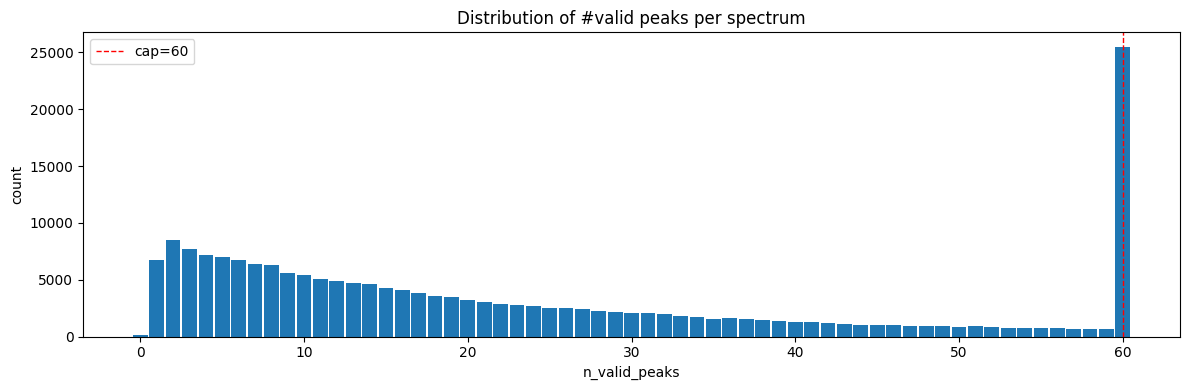

In [6]:
peak_counts = all_labels["n_valid_peaks"]
vals, counts = np.unique(peak_counts, return_counts=True)
order = np.argsort(-counts)

print("Top peak-count frequencies:")
for i in order[:15]:
    print(
        f"  peaks={int(vals[i]):2d}  count={int(counts[i]):6d}  ({counts[i] / peak_counts.size * 100:5.2f}%)"
    )

print(
    f"\n<=5 peaks: {(peak_counts <= 5).sum()} ({(peak_counts <= 5).mean() * 100:.2f}%)"
)
print(
    f"==60 peaks: {(peak_counts == 60).sum()} ({(peak_counts == 60).mean() * 100:.2f}%)"
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(vals, counts, width=0.9, edgecolor="none")
ax.set_title("Distribution of #valid peaks per spectrum")
ax.set_xlabel("n_valid_peaks")
ax.set_ylabel("count")
ax.axvline(60, color="red", linestyle="--", linewidth=1, label="cap=60")
ax.legend()
plt.tight_layout()
plt.show()

## 4. PCA: Variance and Annotated 2D Projection

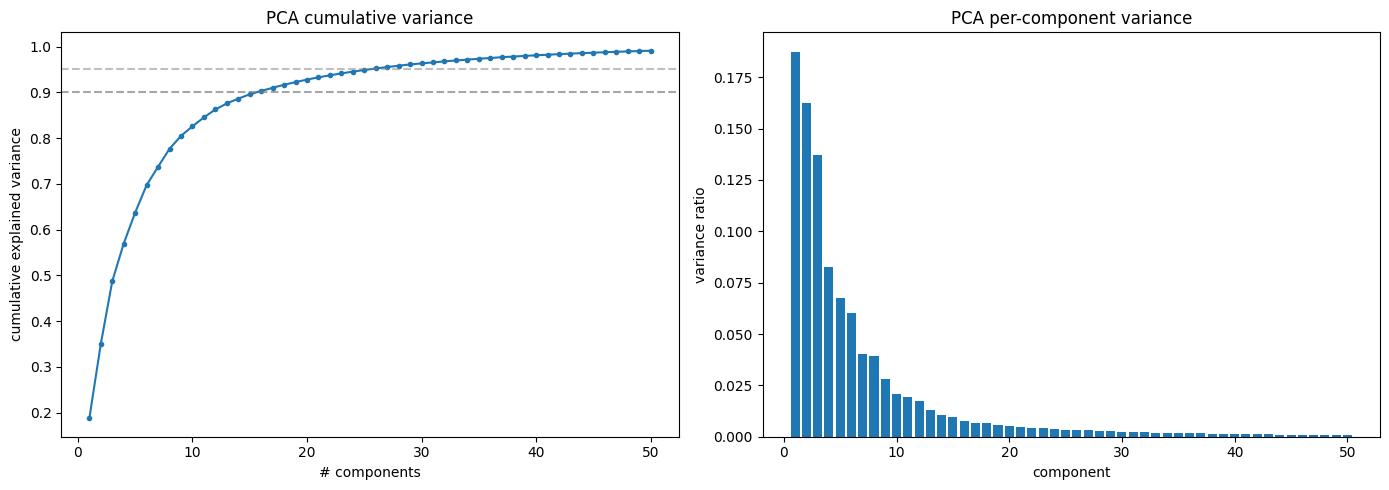

Components for 90% variance: 16
Components for 95% variance: 26
Effective dimensionality (participation ratio): 9.71


In [7]:
pca_full = PCA(n_components=min(50, all_embeds.shape[1]))
pca_full.fit(all_embeds)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.searchsorted(cumvar, 0.90)) + 1
n95 = int(np.searchsorted(cumvar, 0.95)) + 1
pr = (pca_full.explained_variance_ratio_.sum() ** 2) / (
    pca_full.explained_variance_ratio_**2
).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o", markersize=3)
axes[0].axhline(0.90, linestyle="--", color="gray", alpha=0.7)
axes[0].axhline(0.95, linestyle="--", color="gray", alpha=0.5)
axes[0].set_title("PCA cumulative variance")
axes[0].set_xlabel("# components")
axes[0].set_ylabel("cumulative explained variance")

axes[1].bar(
    np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    edgecolor="none",
)
axes[1].set_title("PCA per-component variance")
axes[1].set_xlabel("component")
axes[1].set_ylabel("variance ratio")

plt.tight_layout()
plt.show()

print(f"Components for 90% variance: {n90}")
print(f"Components for 95% variance: {n95}")
print(f"Effective dimensionality (participation ratio): {pr:.2f}")

coords_pca = PCA(n_components=2).fit_transform(all_embeds)

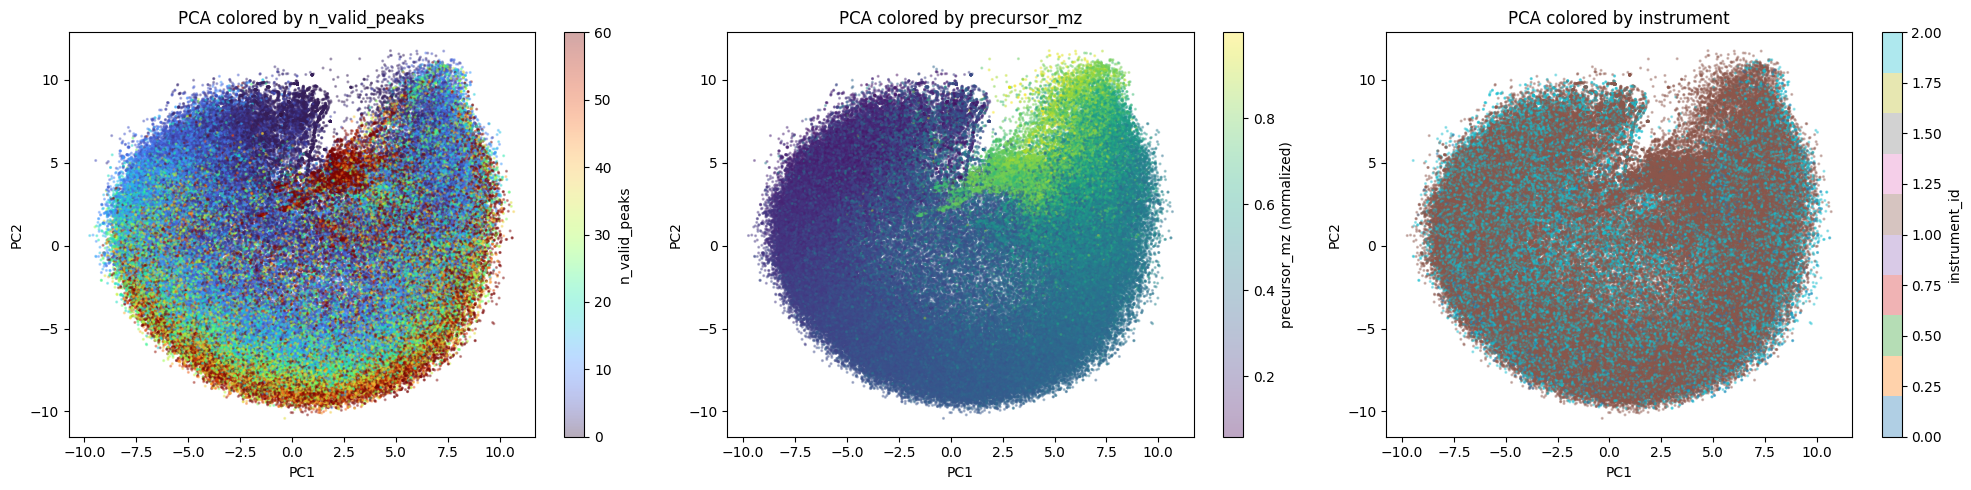

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sc0 = axes[0].scatter(
    coords_pca[:, 0],
    coords_pca[:, 1],
    c=all_labels["n_valid_peaks"],
    cmap="turbo",
    s=1.5,
    alpha=0.35,
    rasterized=True,
)
axes[0].set_title("PCA colored by n_valid_peaks")
plt.colorbar(sc0, ax=axes[0], label="n_valid_peaks")

sc1 = axes[1].scatter(
    coords_pca[:, 0],
    coords_pca[:, 1],
    c=all_labels["precursor_mz"],
    cmap="viridis",
    s=1.5,
    alpha=0.35,
    rasterized=True,
)
axes[1].set_title("PCA colored by precursor_mz")
plt.colorbar(sc1, ax=axes[1], label="precursor_mz (normalized)")

sc2 = axes[2].scatter(
    coords_pca[:, 0],
    coords_pca[:, 1],
    c=all_labels["instrument"],
    cmap="tab10",
    s=1.5,
    alpha=0.35,
    rasterized=True,
)
axes[2].set_title("PCA colored by instrument")
plt.colorbar(sc2, ax=axes[2], label="instrument_id")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

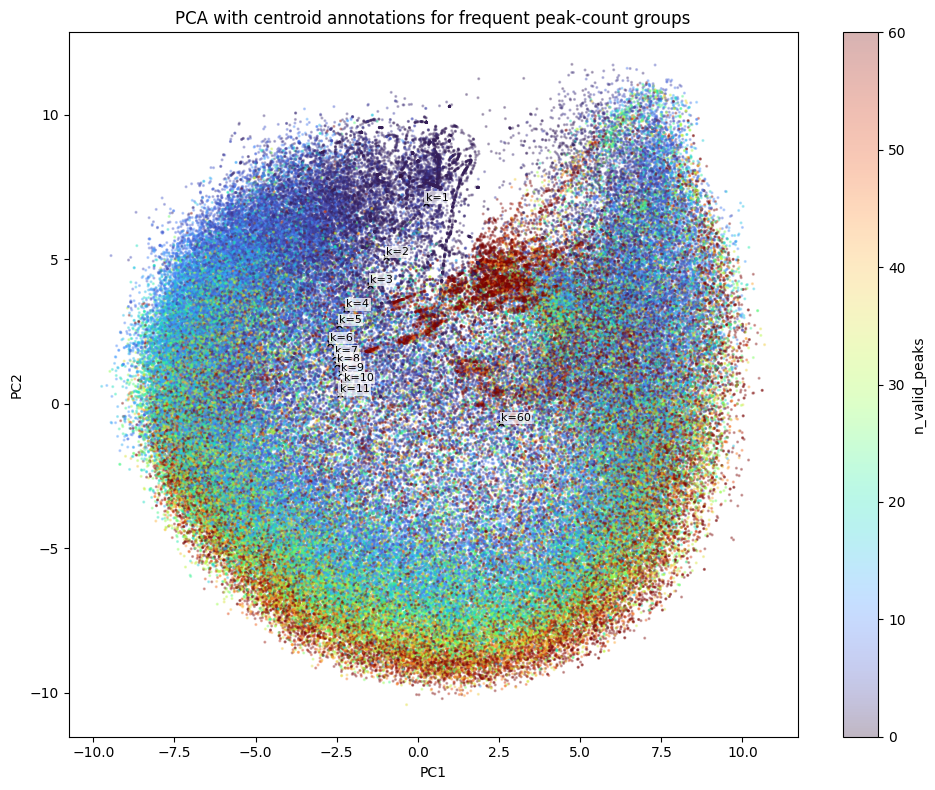

Annotated peak-count groups: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 60]


In [9]:
def annotate_peak_count_centroids(ax, coords, peak_counts, chosen_counts):
    for c in chosen_counts:
        mask = peak_counts == c
        x = np.median(coords[mask, 0])
        y = np.median(coords[mask, 1])
        ax.scatter([x], [y], c="black", s=18, marker="x", linewidths=0.9)
        ax.text(
            x,
            y,
            f"k={int(c)}",
            fontsize=8,
            ha="left",
            va="bottom",
            color="black",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.0),
        )


vals, counts = np.unique(all_labels["n_valid_peaks"], return_counts=True)
chosen_counts = vals[np.argsort(-counts)[:12]]
chosen_counts = np.sort(chosen_counts)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    coords_pca[:, 0],
    coords_pca[:, 1],
    c=all_labels["n_valid_peaks"],
    cmap="turbo",
    s=1.5,
    alpha=0.30,
    rasterized=True,
)
annotate_peak_count_centroids(
    ax, coords_pca, all_labels["n_valid_peaks"], chosen_counts
)

ax.set_title("PCA with centroid annotations for frequent peak-count groups")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.colorbar(sc, ax=ax, label="n_valid_peaks")
plt.tight_layout()
plt.show()

print("Annotated peak-count groups:", chosen_counts.tolist())

## 5. UMAP: Projection and Annotations

In [10]:
n_total = all_embeds.shape[0]
if n_total > UMAP_MAX_SAMPLES:
    rng = np.random.RandomState(RANDOM_SEED)
    sample_idx = rng.choice(n_total, size=UMAP_MAX_SAMPLES, replace=False)
else:
    sample_idx = np.arange(n_total)

umap_embeds = all_embeds[sample_idx]
umap_labels = {k: v[sample_idx] for k, v in all_labels.items()}

print(f"UMAP input shape: {umap_embeds.shape}")
print(
    f"UMAP params: n_neighbors={UMAP_NEIGHBORS}, min_dist={UMAP_MIN_DIST}, metric=cosine"
)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric="cosine",
    random_state=RANDOM_SEED,
)
coords_umap = reducer.fit_transform(umap_embeds)
print(f"coords_umap shape: {coords_umap.shape}")

UMAP input shape: (50000, 256)
UMAP params: n_neighbors=30, min_dist=0.3, metric=cosine


coords_umap shape: (50000, 2)


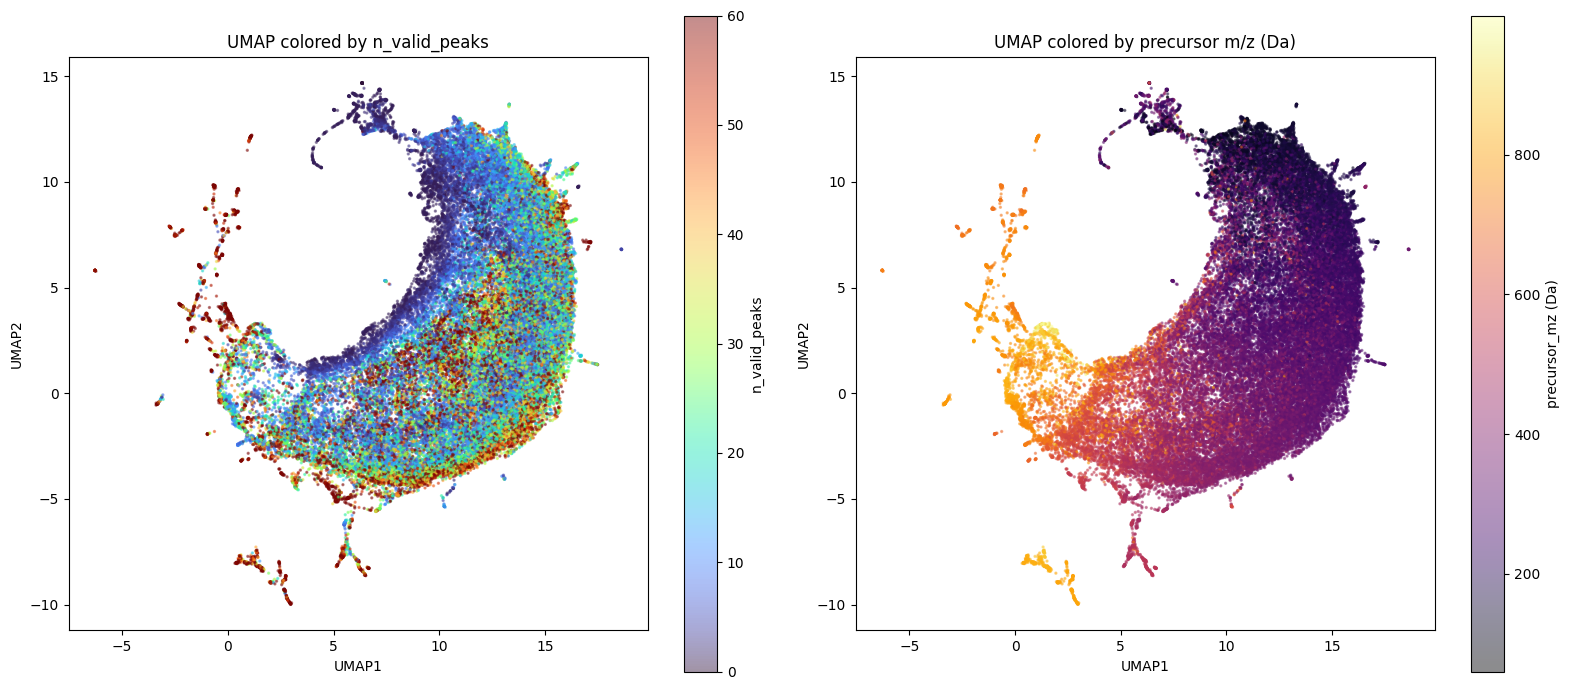

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc0 = axes[0].scatter(
    coords_umap[:, 0],
    coords_umap[:, 1],
    c=umap_labels["n_valid_peaks"],
    cmap="turbo",
    s=2.0,
    alpha=0.45,
    rasterized=True,
)
axes[0].set_title("UMAP colored by n_valid_peaks")
plt.colorbar(sc0, ax=axes[0], label="n_valid_peaks")

sc1 = axes[1].scatter(
    coords_umap[:, 0],
    coords_umap[:, 1],
    c=umap_labels["precursor_mz"] * float(config.max_precursor_mz),
    cmap="inferno",
    s=2.0,
    alpha=0.45,
    rasterized=True,
)
axes[1].set_title("UMAP colored by precursor m/z (Da)")
plt.colorbar(sc1, ax=axes[1], label="precursor_mz (Da)")

for ax in axes:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

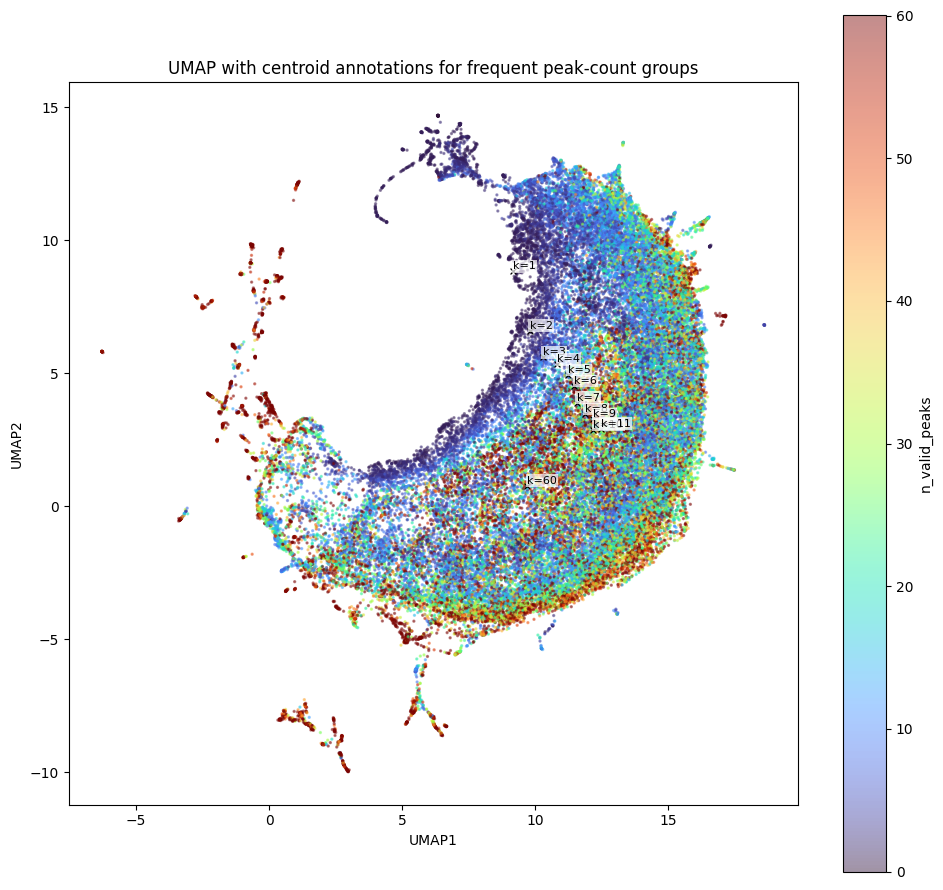

Annotated peak-count groups (UMAP sample): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 60]


In [12]:
vals_u, counts_u = np.unique(umap_labels["n_valid_peaks"], return_counts=True)
chosen_counts_u = vals_u[np.argsort(-counts_u)[:12]]
chosen_counts_u = np.sort(chosen_counts_u)

fig, ax = plt.subplots(figsize=(10, 9))
sc = ax.scatter(
    coords_umap[:, 0],
    coords_umap[:, 1],
    c=umap_labels["n_valid_peaks"],
    cmap="turbo",
    s=2.0,
    alpha=0.45,
    rasterized=True,
)
annotate_peak_count_centroids(
    ax, coords_umap, umap_labels["n_valid_peaks"], chosen_counts_u
)

ax.set_title("UMAP with centroid annotations for frequent peak-count groups")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_aspect("equal")
plt.colorbar(sc, ax=ax, label="n_valid_peaks")
plt.tight_layout()
plt.show()

print("Annotated peak-count groups (UMAP sample):", chosen_counts_u.tolist())

## 6. Quantitative Diagnostics

In [13]:
def corr(a, b):
    return float(np.corrcoef(a, b)[0, 1])


print("PCA axis correlations")
print(
    f"  corr(PC1, n_valid_peaks) = {corr(coords_pca[:, 0], all_labels['n_valid_peaks']): .4f}"
)
print(
    f"  corr(PC2, n_valid_peaks) = {corr(coords_pca[:, 1], all_labels['n_valid_peaks']): .4f}"
)
print(
    f"  corr(PC1, precursor_mz)  = {corr(coords_pca[:, 0], all_labels['precursor_mz']): .4f}"
)
print(
    f"  corr(PC2, precursor_mz)  = {corr(coords_pca[:, 1], all_labels['precursor_mz']): .4f}"
)

print("\nUMAP axis correlations (sampled set)")
print(
    f"  corr(UMAP1, n_valid_peaks) = {corr(coords_umap[:, 0], umap_labels['n_valid_peaks']): .4f}"
)
print(
    f"  corr(UMAP2, n_valid_peaks) = {corr(coords_umap[:, 1], umap_labels['n_valid_peaks']): .4f}"
)
print(
    f"  corr(UMAP1, precursor_mz)  = {corr(coords_umap[:, 0], umap_labels['precursor_mz']): .4f}"
)
print(
    f"  corr(UMAP2, precursor_mz)  = {corr(coords_umap[:, 1], umap_labels['precursor_mz']): .4f}"
)

PCA axis correlations
  corr(PC1, n_valid_peaks) =  0.1393
  corr(PC2, n_valid_peaks) = -0.3435
  corr(PC1, precursor_mz)  =  0.6871
  corr(PC2, precursor_mz)  =  0.1807

UMAP axis correlations (sampled set)
  corr(UMAP1, n_valid_peaks) = -0.1160
  corr(UMAP2, n_valid_peaks) = -0.3333
  corr(UMAP1, precursor_mz)  = -0.8051
  corr(UMAP2, precursor_mz)  = -0.5798


In [14]:
# Connectivity in original high-D space (UMAP sample)
knn = NearestNeighbors(n_neighbors=UMAP_NEIGHBORS, metric="cosine", algorithm="brute")
knn.fit(umap_embeds)
graph_hd = knn.kneighbors_graph(umap_embeds, mode="connectivity")
graph_hd = graph_hd.maximum(graph_hd.T)
num_comp_hd, _ = connected_components(graph_hd, directed=False)

print(f"High-D kNN graph components: {num_comp_hd}")

# Connectivity in 2D UMAP space (radius graph)
knn2 = NearestNeighbors(n_neighbors=6)
knn2.fit(coords_umap)
dists, _ = knn2.kneighbors(coords_umap)
radius = float(np.quantile(dists[:, 1], 0.95) * 2.5)

graph_2d = (
    NearestNeighbors(radius=radius)
    .fit(coords_umap)
    .radius_neighbors_graph(coords_umap, mode="connectivity")
)
graph_2d = graph_2d.maximum(graph_2d.T)
num_comp_2d, comp_2d = connected_components(graph_2d, directed=False)

vals_c, counts_c = np.unique(comp_2d, return_counts=True)
order_c = np.argsort(-counts_c)

print(f"2D radius-graph components: {num_comp_2d} (radius={radius:.4f})")
print("Top component sizes:", counts_c[order_c][:12].tolist())
print("\nLargest component summaries (n_valid_peaks, precursor_mz):")
for comp_id in vals_c[order_c][:10]:
    mask = comp_2d == comp_id
    size = int(mask.sum())
    print(
        f"  comp={int(comp_id):3d} size={size:5d}  "
        f"peaks_mean={umap_labels['n_valid_peaks'][mask].mean():6.2f} "
        f"peaks_range=({umap_labels['n_valid_peaks'][mask].min():2d},{umap_labels['n_valid_peaks'][mask].max():2d}) "
        f"prec_mz_mean={umap_labels['precursor_mz'][mask].mean():.3f}"
    )

High-D kNN graph components: 1


2D radius-graph components: 167 (radius=0.1522)
Top component sizes: [46504, 759, 231, 213, 183, 128, 123, 117, 116, 82, 70, 49]

Largest component summaries (n_valid_peaks, precursor_mz):
  comp=  0 size=46504  peaks_mean= 22.49 peaks_range=( 1,60) prec_mz_mean=0.346
  comp=  2 size=  759  peaks_mean= 28.61 peaks_range=( 1,60) prec_mz_mean=0.829
  comp= 10 size=  231  peaks_mean= 46.76 peaks_range=( 6,60) prec_mz_mean=0.518
  comp=  1 size=  213  peaks_mean= 54.89 peaks_range=(16,60) prec_mz_mean=0.839
  comp=  3 size=  183  peaks_mean= 57.16 peaks_range=(17,60) prec_mz_mean=0.754
  comp=  5 size=  128  peaks_mean= 56.19 peaks_range=( 8,60) prec_mz_mean=0.491
  comp= 17 size=  123  peaks_mean=  1.10 peaks_range=( 1, 2) prec_mz_mean=0.246
  comp=  7 size=  117  peaks_mean= 55.35 peaks_range=( 6,60) prec_mz_mean=0.788
  comp= 14 size=  116  peaks_mean= 29.03 peaks_range=( 5,60) prec_mz_mean=0.195
  comp= 40 size=   82  peaks_mean= 42.90 peaks_range=(16,60) prec_mz_mean=0.562


## 7. Interpretation Checklist

If you observe a segmented shape similar to the one in `debug_probe_executed.ipynb`, this notebook should make it explicit whether:
- the geometry is mainly driven by `n_valid_peaks` (sparsity/length effect),
- precursor m/z is mostly a gradient **inside** those segments,
- and apparent UMAP "disconnections" are 2D separation of weak bridges from a connected high-D graph.